# Analyse exploratoire des donnees (EDA)

Le notebook commence par initialiser l'environnement PostgreSQL du projet : creation de la base, creation des tables brutes, puis chargement des donnees.

Une fois cette couche `raw` en place, l'EDA peut se faire dans un ordre propre : cadrage des tables, visualisation des problemes de donnees, puis choix des traitements a appliquer ensuite dans les tables `processed`.


In [61]:
from pathlib import Path
import sys
import subprocess
import os
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
from dotenv import load_dotenv

project_root = Path.cwd()
if not (project_root / "scripts").exists():
    project_root = project_root.parent

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)


## Initialisation de la base PostgreSQL

On execute ici la pipeline technique minimale du projet :
- creation de la base ;
- creation des tables brutes ;
- chargement des donnees CSV dans PostgreSQL.

L'objectif est de figer une couche `raw` complete avant d'entamer l'analyse.


In [62]:
scripts_dir = project_root / "scripts"
subprocess.run([sys.executable, str(scripts_dir / "create_db.py")], check=True)
subprocess.run([sys.executable, str(scripts_dir / "create_tables.py")], check=True)
subprocess.run([sys.executable, str(scripts_dir / "load_data.py")], check=True)


CompletedProcess(args=['c:\\Users\\kevin\\Documents\\P6\\P6_MLOps_1-2\\.venv\\Scripts\\python.exe', 'c:\\Users\\kevin\\Documents\\P6\\P6_MLOps_1-2\\scripts\\load_data.py'], returncode=0)

In [63]:
load_dotenv(project_root / ".env")
conn = psycopg2.connect(
    host=os.getenv("PGHOST"),
    port=int(os.getenv("PGPORT", 5432)),
    user=os.getenv("PGUSER"),
    password=os.getenv("PGPASSWORD"),
    dbname=os.getenv("PGDATABASE", "home_credit"),
)

raw_counts_query = """
SELECT 'application_train' AS table_name, COUNT(*) AS n_rows FROM application_train
UNION ALL
SELECT 'application_test' AS table_name, COUNT(*) AS n_rows FROM application_test
UNION ALL
SELECT 'bureau' AS table_name, COUNT(*) AS n_rows FROM bureau
UNION ALL
SELECT 'bureau_balance' AS table_name, COUNT(*) AS n_rows FROM bureau_balance
UNION ALL
SELECT 'previous_application' AS table_name, COUNT(*) AS n_rows FROM previous_application
UNION ALL
SELECT 'pos_cash_balance' AS table_name, COUNT(*) AS n_rows FROM pos_cash_balance
UNION ALL
SELECT 'installments_payments' AS table_name, COUNT(*) AS n_rows FROM installments_payments
UNION ALL
SELECT 'credit_card_balance' AS table_name, COUNT(*) AS n_rows FROM credit_card_balance
ORDER BY n_rows DESC
"""

display(pd.read_sql(raw_counts_query, conn))


C:\Users\kevin\AppData\Local\Temp\ipykernel_10400\3655419121.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  display(pd.read_sql(raw_counts_query, conn))


,table_name,n_rows
0,bureau_balance,27299925
1,installments_payments,13605401
2,pos_cash_balance,10001358
3,credit_card_balance,3840312
4,bureau,1716428
5,previous_application,1670214
6,application_train,307511
7,application_test,48744


## Chargement des fichiers CSV dans pandas pour l EDA

Les donnees etant maintenant chargees en base, on charge aussi les CSV dans pandas pour la partie exploratoire visuelle.

Dans ce notebook, l'analyse graphique se fera principalement sur les DataFrames pandas, tandis que PostgreSQL servira de couche `raw` et, plus tard, de support pour les tables `processed`.


In [64]:
base_path = project_root / "data" / "raw"

df_app_test = pd.read_csv(base_path / "application_test.csv")
df_app_train = pd.read_csv(base_path / "application_train.csv")
df_bureau_balance = pd.read_csv(base_path / "bureau_balance.csv")
df_bureau = pd.read_csv(base_path / "bureau.csv")
df_credit_card_balance = pd.read_csv(base_path / "credit_card_balance.csv")
df_hc_columns_description = pd.read_csv(base_path / "HomeCredit_columns_description.csv", encoding="cp1252")
df_install_payments = pd.read_csv(base_path / "installments_payments.csv")
df_pos_cash_balance = pd.read_csv(base_path / "POS_CASH_balance.csv")
df_previous_application = pd.read_csv(base_path / "previous_application.csv")
df_sample_submission = pd.read_csv(base_path / "sample_submission.csv")


## Analyse globale - fichier `application_train.csv`

Ici nous faisons un premier tour d'horizon global sur le DF application_train en réutilisant une fonction développée dans le cadre du projet 4 `eda_overview`

In [65]:
if not (project_root / "src").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.Fonctions_EDA

from src.Fonctions_EDA import eda_overview

eda_overview(df_app_train)


## 1) Vue globale


,n_lignes,n_colonnes,doublons,%_doublons
0,307511,122,0,0.0



## 2) Qualité des colonnes et cardinalité


,dtype,%null,non_null,null,n_uniques
COMMONAREA_AVG,float64,69.87,92646,214865,3181
COMMONAREA_MODE,float64,69.87,92646,214865,3128
COMMONAREA_MEDI,float64,69.87,92646,214865,3202
NONLIVINGAPARTMENTS_AVG,float64,69.43,93997,213514,386
NONLIVINGAPARTMENTS_MODE,float64,69.43,93997,213514,167
NONLIVINGAPARTMENTS_MEDI,float64,69.43,93997,213514,214
LIVINGAPARTMENTS_AVG,float64,68.35,97312,210199,1868
LIVINGAPARTMENTS_MODE,float64,68.35,97312,210199,736
LIVINGAPARTMENTS_MEDI,float64,68.35,97312,210199,1097
FLOORSMIN_AVG,float64,67.85,98869,208642,305



## 3) Variables numériques (106)

### 3.1) Complétude variables numériques


...


### 3.2) Distribution générale variables numériques


,%outliers (IQR),nb_outliers_bas,nb_outliers_haut,min,Q1,median,Q3,max,skew,kurtosis
REGION_RATING_CLIENT,26.19,32197,48330,1.000000e+00,2.000000,2.000000,2.000000,3.000000e+00,0.087468,0.800416
REGION_RATING_CLIENT_W_CITY,25.37,34167,43860,1.000000e+00,2.000000,2.000000,2.000000,3.000000e+00,0.059730,0.933584
DAYS_EMPLOYED,23.48,16843,55374,-1.791200e+04,-2760.000000,-1213.000000,-289.000000,3.652430e+05,1.664346,0.771612
REG_CITY_NOT_WORK_CITY,23.05,0,70867,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+00,1.280138,-0.361250
FLAG_WORK_PHONE,19.94,0,61308,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+00,1.504950,0.264876
AMT_REQ_CREDIT_BUREAU_QRT,19.01,0,50575,0.000000e+00,0.000000,0.000000,0.000000,2.610000e+02,134.365776,43707.464752
FLAG_EMP_PHONE,18.01,55386,0,0.000000e+00,1.000000,1.000000,1.000000,1.000000e+00,-1.664886,0.771852
LIVE_CITY_NOT_WORK_CITY,17.96,0,55215,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+00,1.669795,0.788220
NONLIVINGAPARTMENTS_AVG,16.57,0,15580,0.000000e+00,0.000000,0.000000,0.003900,1.000000e+00,15.541185,284.730336
AMT_REQ_CREDIT_BUREAU_MON,16.45,0,43759,0.000000e+00,0.000000,0.000000,0.000000,2.700000e+01,7.804848,90.434857



## 4) Variables catégorielles (16)


,n_uniques,null,%null,modalite_top,nb_modalite_top
FONDKAPREMONT_MODE,4,210295,68.39,reg oper account,73830
WALLSMATERIAL_MODE,7,156341,50.84,Panel,66040
HOUSETYPE_MODE,3,154297,50.18,block of flats,150503
EMERGENCYSTATE_MODE,2,145755,47.40,No,159428
OCCUPATION_TYPE,18,96391,31.35,Laborers,55186
NAME_TYPE_SUITE,7,1292,0.42,Unaccompanied,248526
ORGANIZATION_TYPE,58,0,0.00,Business Entity Type 3,67992
NAME_INCOME_TYPE,8,0,0.00,Working,158774
WEEKDAY_APPR_PROCESS_START,7,0,0.00,TUESDAY,53901
NAME_FAMILY_STATUS,6,0,0.00,Married,196432



## 5) Variables temporelles (0)

Aucune variable datetime.


## Synthèse de la qualité des données

Le jeu de données contient **307 511 lignes** et **122 colonnes**, avec **0 doublon** détecté.

### Vue d’ensemble

La qualité des données est globalement contrastée. De nombreuses variables liées au logement et aux caractéristiques du bien présentent un **fort taux de valeurs manquantes**, souvent compris entre **50 % et 70 %**, comme `COMMONAREA_*`, `LIVINGAPARTMENTS_*`, `FLOORSMIN_*`, `YEARS_BUILD_*` ou `LANDAREA_*`.  
À l’inverse, les variables financières principales, telles que `AMT_INCOME_TOTAL`, `AMT_CREDIT` et `AMT_ANNUITY`, sont presque entièrement renseignées.

### Variables numériques

Le jeu contient **106 variables numériques**.  
Plusieurs colonnes apparaissent peu informatives en l’état, notamment les variables binaires de type `FLAG_DOCUMENT_*`, qui sont très largement dominées par la valeur `0`, parfois à plus de **99 %**.  
On observe également des distributions **très asymétriques**, ainsi qu’une présence marquée de **valeurs extrêmes** et d’**outliers**, en particulier pour `AMT_INCOME_TOTAL`, `AMT_CREDIT`, `AMT_GOODS_PRICE`, `AMT_REQ_CREDIT_BUREAU_*`, ainsi que pour plusieurs variables immobilières comme `NONLIVINGAREA_*`, `COMMONAREA_*` et `LANDAREA_*`.

Ces éléments suggèrent qu’un travail de **prétraitement** sera nécessaire avant la modélisation, notamment sur :
- l’**imputation** des valeurs manquantes ;
- la **transformation** de certaines distributions ;
- la **sélection** ou la réduction des variables peu informatives.

### Variables catégorielles

Le jeu de données contient **16 variables catégorielles**.  
Certaines sont complètes et directement exploitables, comme `NAME_INCOME_TYPE`, `ORGANIZATION_TYPE`, `NAME_FAMILY_STATUS`, `NAME_HOUSING_TYPE` ou `CODE_GENDER`.  
En revanche, d’autres présentent un **fort taux de valeurs manquantes**, notamment :
- `FONDKAPREMONT_MODE` avec **68,39 %** de valeurs nulles ;
- `WALLSMATERIAL_MODE` avec **50,84 %** ;
- `HOUSETYPE_MODE` avec **50,18 %** ;
- `EMERGENCYSTATE_MODE` avec **47,40 %**.

### Variables temporelles

Aucune variable n’est présente au format `datetime`. Les informations temporelles disponibles sont uniquement encodées sous forme numérique, par exemple avec `DAYS_BIRTH`, `DAYS_EMPLOYED` ou `DAYS_REGISTRATION`.


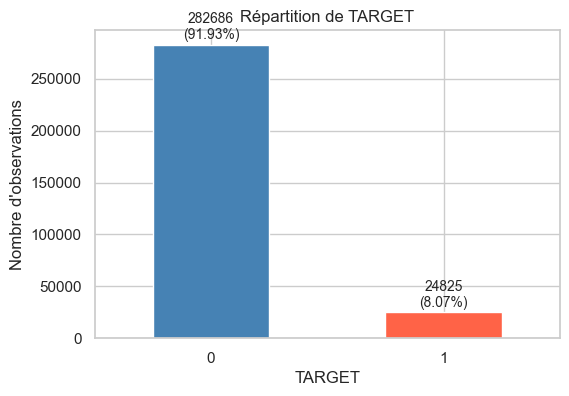

In [66]:
import matplotlib.pyplot as plt

counts = df_app_train["TARGET"].astype(int).value_counts().sort_index()
percentages = counts / counts.sum() * 100

ax = counts.plot.bar(figsize=(6, 4), color=["steelblue", "tomato"])

for i, (count, pct) in enumerate(zip(counts, percentages)):
    ax.text(i, count + counts.max() * 0.01, f"{count}\n({pct:.2f}%)",
            ha="center", va="bottom", fontsize=10)

ax.set_title("Répartition de TARGET")
ax.set_xlabel("TARGET")
ax.set_ylabel("Nombre d'observations")
plt.xticks(rotation=0)
plt.show()


In [67]:
(df_app_train['DAYS_BIRTH'] / -365).describe()

count    307511.000000
mean         43.936973
std          11.956133
min          20.517808
25%          34.008219
50%          43.150685
75%          53.923288
max          69.120548
Name: DAYS_BIRTH, dtype: float64

In [68]:
df_app_train['DAYS_EMPLOYED'].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

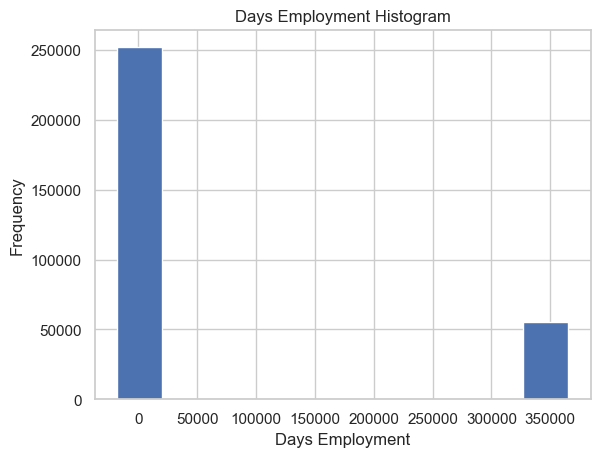

In [69]:
df_app_train['DAYS_EMPLOYED'].plot.hist(title = 'Days Employment Histogram');
plt.xlabel('Days Employment');

Certaines valeurs sont des anomalies `365243`, nous les remplacerons par des valeurs NaN dans un premier temps. 

Regardons maintenant les distributions des variables numériques qui nous semblent pouvoir être les plus informatives

In [70]:
df_app_train.select_dtypes(include="number").columns.tolist()


['SK_ID_CURR',
 'TARGET',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'OWN_CAR_AGE',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_AVG',
 'YEARS_BUILD_AVG',
 'COMMONAREA_AVG',
 'ELEVATORS_AVG',
 'ENTRANCES_AVG',
 'FLOORSMAX_AVG',
 'FLOORSMIN_AVG',
 'LANDAREA_AVG',
 'LIVINGAPARTMENTS_AVG',
 'LIVINGAREA_AVG',
 'NONLIVINGAPARTMENTS_AVG',
 'NONLIVINGAREA_AVG',
 'APARTMENTS_MODE',
 'BASEMENTAR

In [71]:
num_cols = df_app_train.select_dtypes(include="number").columns.drop("target", errors="ignore")

resume = pd.DataFrame({
    "median_0": df_app_train[df_app_train["TARGET"] == 0][num_cols].median(),
    "median_1": df_app_train[df_app_train["TARGET"] == 1][num_cols].median(),
})

resume["diff_mediane"] = resume["median_1"] - resume["median_0"]
resume["diff_abs"] = resume["diff_mediane"].abs()

resume = resume.sort_values("diff_abs", ascending=False)
print(resume)


                                   median_0       median_1  diff_mediane  \
AMT_CREDIT                    517788.000000  497520.000000 -20268.000000   
AMT_INCOME_TOTAL              148500.000000  135000.000000 -13500.000000   
SK_ID_CURR                    278362.500000  276291.000000  -2071.500000   
DAYS_BIRTH                    -15877.000000  -14282.000000   1595.000000   
DAYS_ID_PUBLISH                -3295.000000   -2797.000000    498.000000   
DAYS_REGISTRATION              -4544.000000   -4056.000000    488.000000   
AMT_ANNUITY                    24876.000000   25263.000000    387.000000   
DAYS_EMPLOYED                  -1235.000000   -1034.000000    201.000000   
DAYS_LAST_PHONE_CHANGE          -776.000000    -594.000000    182.000000   
OWN_CAR_AGE                        9.000000      11.000000      2.000000   
AMT_REQ_CREDIT_BUREAU_YEAR         1.000000       2.000000      1.000000   
TARGET                             0.000000       1.000000      1.000000   
EXT_SOURCE_3

C:\Users\kevin\AppData\Local\Temp\ipykernel_10400\2471865802.py:13: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df_app_train, x=col, hue=target, fill=True, common_norm=False, ax=axes[i])


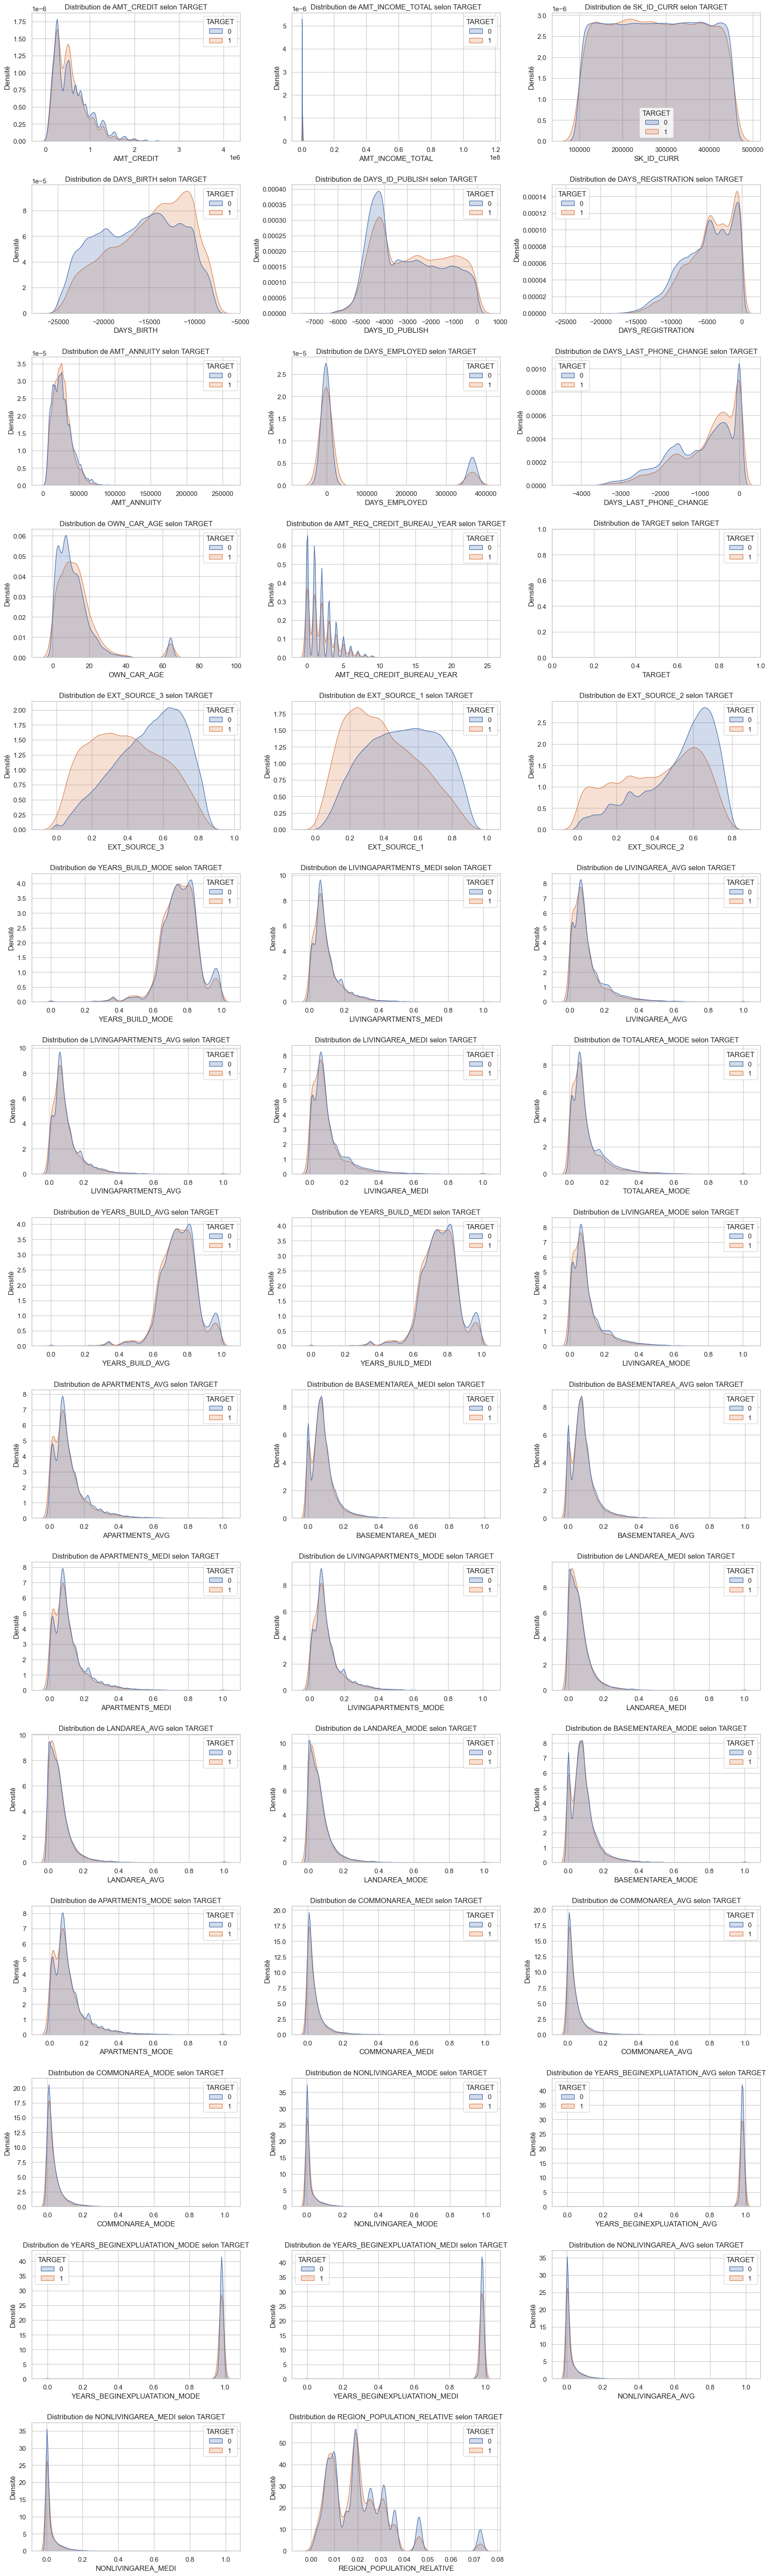

In [72]:
import math

target = "TARGET"

dataviz_cols = resume[resume["diff_mediane"] != 0].index.tolist()
n_cols_plot = 3
n_rows_plot = math.ceil(len(dataviz_cols) / n_cols_plot)

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(18, 4 * n_rows_plot))
axes = axes.flatten()

for i, col in enumerate(dataviz_cols):
    sns.kdeplot(data=df_app_train, x=col, hue=target, fill=True, common_norm=False, ax=axes[i])
    axes[i].set_title(f"Distribution de {col} selon {target}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Densité")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

plt.show()


## Conclusion sur le pouvoir informatif des variables numériques

L’analyse visuelle des distributions par valeur de `TARGET` montre que **certaines variables numériques semblent bien informatives**, mais avec des niveaux de séparation très différents.

### Variables qui paraissent les plus discriminantes
Les variables liées aux **sources de scoring externes** ressortent nettement :
- `EXT_SOURCE_1`
- `EXT_SOURCE_2`
- `EXT_SOURCE_3`

Pour ces variables, les distributions selon `TARGET = 0` et `TARGET = 1` sont **décalées de façon visible**, ce qui suggère un bon pouvoir prédictif. Ce sont clairement les variables les plus prometteuses dans ce lot.

### Variables avec signal modéré
Quelques variables montrent un signal, mais plus faible :
- `DAYS_BIRTH`
- `DAYS_EMPLOYED`
- `DAYS_REGISTRATION`
- `AMT_ANNUITY`
- `ANNUITY_INCOME_RATIO`

On observe des différences de forme ou de position entre les deux classes, mais avec un **recouvrement important**. Elles peuvent donc être utiles, surtout en combinaison avec d’autres variables.

### Variables peu discriminantes visuellement
D’autres variables semblent **peu séparantes** à ce stade :
- `AMT_CREDIT`
- `AMT_INCOME_TOTAL`
- `CNT_FAM_MEMBERS`
- plusieurs ratios/logements de type `AVG`, `MEDI`, `MODE`

Leurs distributions sont très proches entre `TARGET = 0` et `TARGET = 1`, donc leur information univariée paraît limitée.

### Point d’attention
Même lorsque les courbes se recouvrent fortement, une variable peut rester utile dans un modèle :
- grâce à des effets non linéaires
- via des interactions avec d’autres variables
- ou parce qu’elle améliore localement la séparation sur certains segments

### Synthèse
En première lecture :
- les **`EXT_SOURCE_*` sont les variables les plus informatives**
- les variables temporelles comme `DAYS_BIRTH` ou `DAYS_EMPLOYED` apportent un **signal secondaire**
- beaucoup d’autres variables numériques ont un **pouvoir discriminant faible en analyse univariée**

### Recommandation
Pour objectiver cette lecture visuelle, il est pertinent de compléter avec :
- l’écart de médiane ou de moyenne entre classes
- la corrélation avec `TARGET`
- la `mutual_info`
- éventuellement un test univarié de type AUC par variable


In [73]:
target_col = "TARGET"

num_cols = df_app_train.select_dtypes(include="number").columns.drop(target_col, errors="ignore")

resume_corr = pd.DataFrame({
    "correlation_target": df_app_train[num_cols.tolist() + [target_col]]
        .corr(numeric_only=True)[target_col]
        .drop(target_col)
})

resume_corr["correlation_abs"] = resume_corr["correlation_target"].abs()
resume_corr = resume_corr.sort_values("correlation_abs", ascending=False)

resume_corr


,correlation_target,correlation_abs
EXT_SOURCE_3,-0.178919,0.178919
EXT_SOURCE_2,-0.160472,0.160472
EXT_SOURCE_1,-0.155317,0.155317
DAYS_BIRTH,0.078239,0.078239
REGION_RATING_CLIENT_W_CITY,0.060893,0.060893
REGION_RATING_CLIENT,0.058899,0.058899
DAYS_LAST_PHONE_CHANGE,0.055218,0.055218
DAYS_ID_PUBLISH,0.051457,0.051457
REG_CITY_NOT_WORK_CITY,0.050994,0.050994
FLAG_EMP_PHONE,0.045982,0.045982


## Interprétation des corrélations avec `TARGET`

Globalement, les corrélations linéaires avec la target restent **plutôt faibles en valeur absolue**, ce qui est classique sur ce type de problème. Cela signifie qu’aucune variable prise isolément n’explique fortement le défaut, mais certaines apportent tout de même un **signal univarié utile**.

### Variables les plus informatives
Les variables les plus corrélées à `TARGET` sont clairement :
- `EXT_SOURCE_3` (`-0.179`)
- `EXT_SOURCE_2` (`-0.160`)
- `EXT_SOURCE_1` (`-0.155`)

Ce sont les variables qui ressortent le plus nettement. Leur corrélation **négative** indique que des valeurs plus élevées de ces scores sont associées à une **probabilité plus faible de défaut** (`TARGET = 1`).

### Variables apportant un signal secondaire
Derrière les `EXT_SOURCE_*`, quelques variables montrent un signal plus modéré :
- `DAYS_BIRTH`
- `REGION_RATING_CLIENT_W_CITY`
- `REGION_RATING_CLIENT`
- `DAYS_LAST_PHONE_CHANGE`
- `DAYS_ID_PUBLISH`
- `REG_CITY_NOT_WORK_CITY`
- `FLAG_EMP_PHONE`

Ces corrélations restent modestes, mais elles peuvent être utiles dans un modèle, en particulier en combinaison avec d’autres variables.

### Sens d’interprétation
Il faut faire attention au sens métier de certaines variables, notamment celles en `DAYS_*`, souvent codées en **jours négatifs**. Par exemple :
- une corrélation positive pour `DAYS_BIRTH` ne veut pas dire “plus âgé = plus de défaut” de façon directe ;
- elle reflète surtout le codage de la variable, donc l’interprétation métier doit être faite avec prudence.

### Variables peu utiles en univarié
Une grande partie des variables a une corrélation très proche de `0`, par exemple :
- `AMT_INCOME_TOTAL`
- `CNT_FAM_MEMBERS`
- plusieurs `FLAG_DOCUMENT_*`
- `FLAG_MOBIL`, `FLAG_CONT_MOBILE`

Cela suggère un **faible pouvoir explicatif linéaire isolé**. Elles ne sont pas forcément inutiles, mais elles ne semblent pas très discriminantes seules.

### Conclusion
Les résultats confirment que :
- les **`EXT_SOURCE_*` dominent nettement** en analyse univariée ;
- quelques variables démographiques, géographiques et comportementales apportent un **signal complémentaire** ;
- beaucoup de variables ont une corrélation faible et devront surtout être exploitées via des **interactions**, des **effets non linéaires** ou la **modélisation multivariée**.

### Limite de l’analyse
La corrélation avec une target binaire reste un indicateur simple :
- elle mesure surtout une relation **linéaire** ;
- elle peut sous-estimer des variables utiles mais non monotones ;
- elle ne remplace pas une analyse de type **importance de variables**, **mutual information** ou **modèle supervisé**.


In [74]:
from scipy.stats import chi2_contingency

cat_cols = df_app_train.select_dtypes(include=["object", "string", "category"]).columns.tolist()

chi2_rows = []

for col in cat_cols:
    tmp = df_app_train[[col, target_col]].copy()
    tmp[col] = tmp[col].fillna("__MISSING__")

    table = pd.crosstab(tmp[col], tmp[target_col])

    if table.shape[0] >= 2 and table.shape[1] >= 2:
        chi2, p_value, dof, expected = chi2_contingency(table)
        chi2_rows.append({
            "variable": col,
            "chi2": chi2,
            "p_value": p_value,
            "nb_modalites": table.shape[0]
        })

chi2_cats = pd.DataFrame(chi2_rows).sort_values(["p_value", "chi2"], ascending=[True, False])

print(chi2_cats)

                      variable         chi2        p_value  nb_modalites
9              OCCUPATION_TYPE  1975.082752   0.000000e+00            19
11           ORGANIZATION_TYPE  1609.240636  5.224541e-299            58
5             NAME_INCOME_TYPE  1253.470808  1.928146e-266             8
6          NAME_EDUCATION_TYPE  1019.213187  2.447681e-219             5
1                  CODE_GENDER   920.791334  1.129022e-200             3
14          WALLSMATERIAL_MODE   599.041379  3.916842e-125             8
15         EMERGENCYSTATE_MODE   547.975997  1.019821e-119             3
13              HOUSETYPE_MODE   509.405086  4.369310e-110             4
7           NAME_FAMILY_STATUS   504.694083  7.744842e-107             6
8            NAME_HOUSING_TYPE   420.556190   1.099089e-88             6
0           NAME_CONTRACT_TYPE   293.150542   1.023515e-65             2
12          FONDKAPREMONT_MODE   281.716375   9.504317e-60             5
2                 FLAG_OWN_CAR   146.656018   9.330

## Interprétation de l’analyse des variables catégorielles

Le test du chi-deux montre que plusieurs variables catégorielles sont **significativement liées** à la target `TARGET`. Les variables qui ressortent le plus sont :

- `OCCUPATION_TYPE`
- `ORGANIZATION_TYPE`
- `NAME_INCOME_TYPE`
- `NAME_EDUCATION_TYPE`
- `CODE_GENDER`

Ces variables semblent donc porter une information utile sur le risque de défaut, au moins en analyse univariée.

### Variables les plus informatives
Les plus fortes statistiques de chi-deux sont observées pour :
- `OCCUPATION_TYPE`
- `ORGANIZATION_TYPE`
- `NAME_INCOME_TYPE`
- `NAME_EDUCATION_TYPE`

Cela suggère que le **niveau de risque varie selon les modalités** de profession, d’organisation employeur, de type de revenu et de niveau d’éducation. Ces variables sont donc de bonnes candidates pour une analyse plus détaillée par modalité.

### Variables également significatives
D’autres variables montrent aussi une association statistiquement forte avec la target :
- `CODE_GENDER`
- `WALLSMATERIAL_MODE`
- `EMERGENCYSTATE_MODE`
- `HOUSETYPE_MODE`
- `NAME_FAMILY_STATUS`
- `NAME_HOUSING_TYPE`

Elles paraissent moins structurantes que les précédentes, mais elles peuvent contribuer au modèle, notamment si elles interagissent avec d’autres variables.

### Variables plus faibles mais non nulles
Les variables suivantes ressortent avec un signal plus limité :
- `FLAG_OWN_CAR`
- `NAME_TYPE_SUITE`
- `FLAG_OWN_REALTY`
- `WEEKDAY_APPR_PROCESS_START`

Leur lien avec la target existe statistiquement, mais il semble plus faible en pratique.

### Point d’attention sur l’interprétation
Il faut rester prudent avec le chi-deux :
- sur un grand volume de données, des écarts faibles peuvent devenir **très significatifs**
- une `p_value` très petite ne signifie pas forcément que l’effet est **fort**
- la statistique du chi-deux est aussi influencée par le **nombre de modalités**

Ainsi, `ORGANIZATION_TYPE` a probablement une forte statistique aussi parce qu’elle comporte beaucoup de modalités (`58`).

### Conclusion
Cette analyse suggère que les variables catégorielles les plus prometteuses sont surtout celles décrivant :
- la **profession**
- le **type d’organisation**
- le **type de revenu**
- le **niveau d’éducation**
- certaines caractéristiques sociodémographiques ou de logement

La suite logique est de regarder, pour ces variables, le **taux de défaut par modalité**, afin d’identifier quelles catégories sont les plus risquées et lesquelles pourraient être regroupées.


In [75]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

target_col = "TARGET"

cat_cols = df_app_train.select_dtypes(include=["object", "string", "category"]).columns.tolist()

def cramers_v(x, y):
    table = pd.crosstab(x, y)

    if table.shape[0] < 2 or table.shape[1] < 2:
        return np.nan

    chi2 = chi2_contingency(table)[0]
    n = table.to_numpy().sum()

    if n == 0:
        return np.nan

    r, k = table.shape
    denom = min(r - 1, k - 1)

    if denom == 0:
        return np.nan

    return np.sqrt(chi2 / (n * denom))

cramer_rows = []

for col in cat_cols:
    tmp = df_app_train[[col, target_col]].copy()
    tmp[col] = tmp[col].fillna("__MISSING__")

    v = cramers_v(tmp[col], tmp[target_col])

    cramer_rows.append({
        "variable": col,
        "cramers_v": v,
        "nb_modalites": tmp[col].nunique(dropna=False)
    })

cramers_v_cats = (
    pd.DataFrame(cramer_rows)
    .sort_values("cramers_v", ascending=False)
    .reset_index(drop=True)
)

cramers_v_cats


,variable,cramers_v,nb_modalites
0,OCCUPATION_TYPE,0.080142,19
1,ORGANIZATION_TYPE,0.072340,58
2,NAME_INCOME_TYPE,0.063845,8
3,NAME_EDUCATION_TYPE,0.057571,5
4,CODE_GENDER,0.054721,3
5,WALLSMATERIAL_MODE,0.044137,8
6,EMERGENCYSTATE_MODE,0.042213,3
7,HOUSETYPE_MODE,0.040701,4
8,NAME_FAMILY_STATUS,0.040512,6
9,NAME_HOUSING_TYPE,0.036981,6


## Interprétation du V de Cramer

Le `V de Cramer` confirme que plusieurs variables catégorielles sont bien associées à `TARGET`, mais avec une **force d’association globalement faible à modérée**. C’est cohérent avec un problème de scoring où aucune variable catégorielle seule n’explique fortement le défaut.

### Variables catégorielles les plus informatives
Les variables qui ressortent le plus sont :
- `OCCUPATION_TYPE` (`0.080`)
- `ORGANIZATION_TYPE` (`0.072`)
- `NAME_INCOME_TYPE` (`0.064`)
- `NAME_EDUCATION_TYPE` (`0.058`)
- `CODE_GENDER` (`0.055`)

Ce sont les variables catégorielles les plus liées à la target dans cette analyse univariée. Elles semblent donc être les meilleures candidates pour une exploration plus détaillée par modalité.

### Niveau global du signal
Les valeurs restent relativement basses :
- aucune variable n’atteint `0.10`
- la plupart sont comprises entre `0.02` et `0.08`

Cela indique que l’association existe, mais qu’elle reste **limitée prise isolément**. En pratique, ces variables peuvent être utiles dans un modèle, mais surtout **en combinaison** avec d’autres variables numériques et catégorielles.

### Variables à signal plus faible
Les variables suivantes semblent moins informatives :
- `NAME_CONTRACT_TYPE`
- `FONDKAPREMONT_MODE`
- `FLAG_OWN_CAR`

Et les plus faibles du lot sont :
- `NAME_TYPE_SUITE`
- `WEEKDAY_APPR_PROCESS_START`
- `FLAG_OWN_REALTY`

Leur contribution univariée paraît donc plus marginale.

### Conclusion
Cette analyse confirme que les variables catégorielles les plus intéressantes concernent principalement :
- la **profession**
- le **type d’organisation**
- le **type de revenu**
- le **niveau d’éducation**
- certaines caractéristiques sociodémographiques

Toutefois, même les meilleures variables catégorielles ont ici un **pouvoir explicatif modéré**. Leur intérêt sera probablement plus fort dans une logique de **modélisation multivariée** que dans une lecture isolée.


In [76]:
import pandas as pd
import numpy as np

target_col = "TARGET"
id_col = "SK_ID_CURR"

flag_cols = [
    col for col in df_app_train.columns
    if col not in [target_col, id_col] and df_app_train[col].dropna().nunique() == 2
]

rows = []

for col in flag_cols:
    tmp = df_app_train[[col, target_col]].dropna().copy()

    grp = (
        tmp.groupby(col)[target_col]
        .agg(nb_obs="count", nb_target_1="sum", taux_target_1="mean")
        .reindex([0, 1], fill_value=0)
    )

    nb_0 = grp.loc[0, "nb_obs"]
    nb_1 = grp.loc[1, "nb_obs"]

    taux_0 = grp.loc[0, "taux_target_1"] if nb_0 > 0 else np.nan
    taux_1 = grp.loc[1, "taux_target_1"] if nb_1 > 0 else np.nan

    diff = taux_1 - taux_0 if pd.notna(taux_0) and pd.notna(taux_1) else np.nan
    diff_abs = abs(diff) if pd.notna(diff) else np.nan

    rows.append({
        "variable": col,
        "nb_flag_0": int(nb_0),
        "nb_flag_1": int(nb_1),
        "nb_target1_flag_0": int(grp.loc[0, "nb_target_1"]),
        "nb_target1_flag_1": int(grp.loc[1, "nb_target_1"]),
        "taux_target1_flag_0": taux_0,
        "taux_target1_flag_1": taux_1,
        "diff_taux_1_moins_0": diff,
        "diff_abs": diff_abs
    })

resume_flags = (
    pd.DataFrame(rows)
    .sort_values("diff_abs", ascending=False, na_position="last")
    .reset_index(drop=True)
)

resume_flags


import pandas as pd

target_col = "TARGET"
id_col = "SK_ID_CURR"

# 1. Seuils de sélection
seuil_corr_num = 0.02
seuil_diff_flag = 0.01
seuil_cramers_v = 0.03

# 2. Variables numériques retenues
selected_num_cols = (
    resume_corr.loc[resume_corr["correlation_abs"] >= seuil_corr_num]
    .index
    .tolist()
)

# 3. Variables flags retenues
selected_flag_cols = (
    resume_flags.loc[resume_flags["diff_abs"] >= seuil_diff_flag, "variable"]
    .tolist()
)

# 4. Variables catégorielles retenues
selected_cat_cols = (
    cramers_v_cats.loc[cramers_v_cats["cramers_v"] >= seuil_cramers_v, "variable"]
    .tolist()
)

# 5. Union finale des variables + conservation explicite de l'identifiant client
selected_features = sorted(
    set([id_col] + selected_num_cols + selected_flag_cols + selected_cat_cols)
)

print("Nombre de variables numériques retenues :", len(selected_num_cols))
print("Nombre de flags retenus :", len(selected_flag_cols))
print("Nombre de variables catégorielles retenues :", len(selected_cat_cols))
print("Nombre total de variables retenues :", len(selected_features))
print("SK_ID_CURR conservé :", id_col in selected_features)


Nombre de variables numériques retenues : 49
Nombre de flags retenus : 25
Nombre de variables catégorielles retenues : 12
Nombre total de variables retenues : 79
SK_ID_CURR conservé : True


In [77]:
# Train
df_app_train_processed = df_app_train[selected_features + [target_col]].copy()

# Test
selected_features_test = [col for col in selected_features if col in df_app_test.columns]
df_app_test_processed = df_app_test[selected_features_test].copy()

print(df_app_train_processed.shape)
print(df_app_test_processed.shape)


(307511, 80)
(48744, 79)


In [78]:
train_features = [c for c in df_app_train_processed.columns if c != "TARGET"]
test_features = df_app_test_processed.columns.tolist()

print(train_features == test_features)

True


In [79]:
import pandas as pd

target_col = "TARGET"
id_col = "SK_ID_CURR"

# Colonnes numériques hors target et hors identifiant client
num_cols = df_app_train_processed.select_dtypes(include="number").columns.tolist()
num_cols = [col for col in num_cols if col not in [target_col, id_col]]

# Optionnel : exclure les flags binaires
num_cols = [col for col in num_cols if df_app_train_processed[col].dropna().nunique() > 2]

# Bornes calculées sur le train
lower_q = df_app_train_processed[num_cols].quantile(0.01)
upper_q = df_app_train_processed[num_cols].quantile(0.99)

# Masque : ligne conservée si toutes les variables sont dans les bornes
mask_keep = ~(
    (df_app_train_processed[num_cols] < lower_q) |
    (df_app_train_processed[num_cols] > upper_q)
).any(axis=1)

df_app_train_no_outliers = df_app_train_processed.loc[mask_keep].copy()

print("Shape avant :", df_app_train_processed.shape)
print("Shape après :", df_app_train_no_outliers.shape)
print("Nb lignes supprimées :", (~mask_keep).sum())


Shape avant : (307511, 80)
Shape après : (251289, 80)
Nb lignes supprimées : 56222


In [80]:
from pathlib import Path

project_root = Path.cwd()
if not (project_root / "scripts").exists():
    project_root = project_root.parent

output_dir = project_root / "data" / "processed"
output_dir.mkdir(parents=True, exist_ok=True)

df_app_train_no_outliers.to_csv(output_dir / "df_app_train_processed.csv", index=False)
df_app_test_processed.to_csv(output_dir / "df_app_test_processed.csv", index=False)

print("Train exporté :", df_app_train_no_outliers.shape)
print("Test exporté  :", df_app_test_processed.shape)


Train exporté : (251289, 80)
Test exporté  : (48744, 79)


Maintenant qu'on a fait un point zéro sur le fichier principal train et test. Nous allons créer une table postgreSQL, importer les données à l'intérieur et récupérer les données qui nous paraissent être pertinentes depuis les autres tables.

In [81]:
from pathlib import Path
from io import StringIO
import os

import pandas as pd
import psycopg2
from psycopg2 import sql
from dotenv import load_dotenv

project_root = Path.cwd()
if not (project_root / "scripts").exists():
    project_root = project_root.parent

load_dotenv(project_root / ".env")

conn = psycopg2.connect(
    host=os.getenv("PGHOST"),
    port=int(os.getenv("PGPORT", 5432)),
    user=os.getenv("PGUSER"),
    password=os.getenv("PGPASSWORD"),
    dbname=os.getenv("PGDATABASE", "home_credit"),
)

processed_dir = project_root / "data" / "processed"
train_csv = processed_dir / "df_app_train_processed.csv"
test_csv = processed_dir / "df_app_test_processed.csv"

print(train_csv)
print(test_csv)


c:\Users\kevin\Documents\P6\P6_MLOps_1-2\data\processed\df_app_train_processed.csv
c:\Users\kevin\Documents\P6\P6_MLOps_1-2\data\processed\df_app_test_processed.csv


In [82]:
def map_dtype_to_postgres(dtype) -> str:
    if pd.api.types.is_integer_dtype(dtype):
        return "BIGINT"
    if pd.api.types.is_float_dtype(dtype):
        return "DOUBLE PRECISION"
    if pd.api.types.is_bool_dtype(dtype):
        return "BOOLEAN"
    if pd.api.types.is_datetime64_any_dtype(dtype):
        return "TIMESTAMP"
    return "TEXT"


def infer_columns_from_csv(csv_path: Path, nrows: int = 5000) -> list[tuple[str, str]]:
    sample = pd.read_csv(csv_path, nrows=nrows, low_memory=False)
    return [(col, map_dtype_to_postgres(dtype)) for col, dtype in sample.dtypes.items()]


def create_table_from_csv(
    conn,
    schema_name: str,
    table_name: str,
    csv_path: Path,
    drop_if_exists: bool = True,
    nrows_inference: int = 5000,
) -> None:
    columns = infer_columns_from_csv(csv_path, nrows=nrows_inference)

    column_defs = [
        sql.SQL("{} {}").format(sql.Identifier(col_name), sql.SQL(pg_type))
        for col_name, pg_type in columns
    ]

    with conn.cursor() as cur:
        cur.execute(sql.SQL("CREATE SCHEMA IF NOT EXISTS {}").format(sql.Identifier(schema_name)))

        if drop_if_exists:
            cur.execute(
                sql.SQL("DROP TABLE IF EXISTS {}.{}").format(
                    sql.Identifier(schema_name),
                    sql.Identifier(table_name),
                )
            )

        cur.execute(
            sql.SQL("CREATE TABLE {}.{} ({})").format(
                sql.Identifier(schema_name),
                sql.Identifier(table_name),
                sql.SQL(", ").join(column_defs),
            )
        )

    conn.commit()


def copy_csv_to_table(conn, schema_name: str, table_name: str, csv_path: Path) -> None:
    copy_query = sql.SQL(
        """
        COPY {}.{} FROM STDIN
        WITH (
            FORMAT CSV,
            HEADER TRUE,
            DELIMITER ',',
            QUOTE '"'
        )
        """
    ).format(
        sql.Identifier(schema_name),
        sql.Identifier(table_name),
    )

    with conn.cursor() as cur:
        with csv_path.open("r", encoding="utf-8") as f:
            cur.copy_expert(copy_query.as_string(conn), f)

    conn.commit()


In [83]:
create_table_from_csv(
    conn=conn,
    schema_name="processed",
    table_name="app_train_processed",
    csv_path=train_csv,
)

copy_csv_to_table(
    conn=conn,
    schema_name="processed",
    table_name="app_train_processed",
    csv_path=train_csv,
)

create_table_from_csv(
    conn=conn,
    schema_name="processed",
    table_name="app_test_processed",
    csv_path=test_csv,
)

copy_csv_to_table(
    conn=conn,
    schema_name="processed",
    table_name="app_test_processed",
    csv_path=test_csv,
)


In [84]:
print("Train final exporté :", df_app_train_no_outliers.shape)
print("Test final exporté  :", df_app_test_processed.shape)


Train final exporté : (251289, 80)
Test final exporté  : (48744, 79)


In [85]:
check_query = """
SELECT 'processed.app_train_processed' AS table_name, COUNT(*) AS n_rows
FROM processed.app_train_processed
UNION ALL
SELECT 'processed.app_test_processed' AS table_name, COUNT(*) AS n_rows
FROM processed.app_test_processed
"""

df_check = pd.read_sql(check_query, conn)
df_check


C:\Users\kevin\AppData\Local\Temp\ipykernel_10400\873729326.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_check = pd.read_sql(check_query, conn)


,table_name,n_rows
0,processed.app_test_processed,48744
1,processed.app_train_processed,251289
